# Coloration de graphes — validité statistique d'une comparaison de stratégies

**Notebook compagnon de [`App-2-GraphColoring.ipynb`](App-2-GraphColoring.ipynb).**

Le notebook `App-2` compare trois stratégies de coloration — **glouton** séquentiel, **DSATUR** (degré de saturation) et **CP-SAT** (numérotation chromatique exacte via OR-Tools) — sur un graphe aléatoire et conclut, par exemple, que « CP-SAT utilise 18 couleurs, DSATUR 19, le glouton 22 ». Mais cette conclusion repose sur **une seule instance**. Or le graphe tiré au hasard n'est qu'**un tirage** parmi une infinité de graphes de même taille et même densité : un autre tirage pourrait rapprocher les stratégies, voire les inverser sur certaines métriques.

Ce notebook pose la question méthodologique qui manque à `App-2` : **quand peut-on affirmer qu'une stratégie est *significativement* meilleure qu'une autre**, plutôt que d'avoir observé un écart dû au hasard de l'échantillonnage des graphes ?

## Plan

1. **Le piège de l'instance unique** — pourquoi une comparaison ponctuelle n'est pas une preuve.
2. **Distribution *cross-instance*** — échantillonner $N$ graphes d'Erdős-Rényi $G(n,p)$ et regarder la distribution du nombre de couleurs de chaque stratégie.
3. **Intervalle de confiance bootstrap à 95 %** — encadrer l'écart moyen sans hypothèse de normalité.
4. **Test de Mann-Whitney par paires** — l'écart est-il statistiquement significatif ? (+ correction de Bonferroni pour les comparaisons multiples).
5. **Taille d'effet *rank-biserial*** — significatif $\neq$ important.
6. **Effet de la densité** — le gap glouton/DSATUR dépend-il de $p$ ?

> **Famille conceptuelle.** Ce notebook est le troisième d'une veine « validité statistique d'une comparaison » : [`Sudoku-18b`](../../../Sudoku/Sudoku-18b-Statistical-Comparison-Python.ipynb) étudie la variance du **temps** de solveurs déterministes ; `ML-4b` (série ML) étudie la variance des **métriques** d'un modèle en cross-validation. Ici, la stochasticité est d'une autre nature : elle vient de la **génération aléatoire des instances** (le graphe lui-même), pas du temps système ni de l'initialisation. Les stratégies sont déterministes, mais la *question posée* — « sur quels graphes cette stratégie gagne-t-elle ? » — est aléatoire.

**Pré-requis :** avoir parcouru `App-2-GraphColoring` (définitions de coloration, nombre chromatique $\chi$, principe du glouton / DSATUR / CP-SAT).

## 1. Mise en place — trois stratégies de coloration

Nous réimplémentons les trois stratégies de `App-2` sous une forme minimale et commentée, afin de pouvoir les lancer sur $N$ graphes sans dépendre d'artefacts extérieurs. La stack est la même que `App-2` : `networkx` (graphes), `ortools.sat.python.cp_model` (CP-SAT), plus `numpy` / `scipy` / `matplotlib` pour la statistique et les figures.

> **Reproductibilité.** Toute la génération aléatoire est contrôlée par une graine fixée (`SEED = 42`). Les stratégies elles-mêmes sont déterministes : relancer ce notebook donne **byte-à-byte** les mêmes nombres. La seule source de variabilité que nous étudions est donc bien celle des *instances* (les graphes), pas celle du matériel ou de l'initialisation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
from ortools.sat.python import cp_model

SEED = 42
rng = np.random.default_rng(SEED)

# Style des figures
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})


def greedy_color(G, order=None):
    """Glouton séquentiel : couleur la plus basse non utilisée par les voisins.
    `order` = ordre des sommets (par défaut, l'ordre networkx)."""
    nodes = list(G.nodes()) if order is None else order
    color = {}
    for u in nodes:
        used = {color[v] for v in G[u] if v in color}
        c = 0
        while c in used:
            c += 1
        color[u] = c
    return max(color.values()) + 1 if color else 0


def dsatur_color(G):
    """DSATUR : à chaque pas, colorer le sommet de saturation maximale
    (nombre de couleurs distinctes parmi les voisins déjà colorés),
    départage les égalités par le degré décroissant."""
    color = {}
    saturation = {u: 0 for u in G}
    degree = dict(G.degree())
    while len(color) < len(G):
        u = max((v for v in G if v not in color),
                key=lambda v: (saturation[v], degree[v]))
        used = {color[v] for v in G[u] if v in color}
        c = 0
        while c in used:
            c += 1
        color[u] = c
        for w in G[u]:
            if w not in color:
                saturation[w] = len({color[v] for v in G[w] if v in color})
    return max(color.values()) + 1


def cpsat_color(G, time_limit=2.0):
    """Nombre chromatique exact via CP-SAT (OR-Tools).
    Borné supérieurement par le glouton pour réduire l'espace de recherche."""
    n = len(G)
    if n == 0:
        return 0
    nodes = list(G.nodes())
    idx = {u: i for i, u in enumerate(nodes)}
    ub = greedy_color(G)  # borne supérieure = résultat glouton
    model = cp_model.CpModel()
    x = {(v, c): model.NewBoolVar(f"x_{v}_{c}")
         for v in range(n) for c in range(ub)}
    for v in range(n):
        model.Add(sum(x[(v, c)] for c in range(ub)) == 1)
    for u, w in G.edges():
        iu, iw = idx[u], idx[w]
        for c in range(ub):
            model.Add(x[(iu, c)] + x[(iw, c)] <= 1)
    used = []
    for c in range(ub):
        uc = model.NewBoolVar(f"used_{c}")
        model.AddMaxEquality(uc, [x[(v, c)] for v in range(n)])
        used.append(uc)
    model.Minimize(sum(used))
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = 4
    status = solver.Solve(model)
    return int(round(solver.ObjectiveValue())) if status in (cp_model.OPTIMAL, cp_model.FEASIBLE) else ub


print("Stratégies chargées : glouton, DSATUR, CP-SAT.")

Stratégies chargées : glouton, DSATUR, CP-SAT.


## 2. Le piège de l'instance unique

Comparons les trois stratégies sur **un seul** graphe $G(50, 0{,}4)$, comme le ferait une conclusion ponctuelle :

In [2]:
G_one = nx.gnp_random_graph(50, 0.4, seed=42)
g1, d1, c1 = greedy_color(G_one), dsatur_color(G_one), cpsat_color(G_one)
print(f"Une instance G(50, 0.4) : glouton={g1}, DSATUR={d1}, CP-SAT={c1}")
print(f"Écart glouton→CP-SAT : {g1 - c1} couleurs.")

Une instance G(50, 0.4) : glouton=12, DSATUR=9, CP-SAT=8
Écart glouton→CP-SAT : 4 couleurs.


Faut-il en conclure que DSATUR est « meilleure » que le glouton de ${g1 - d1}$ couleurs, et CP-SAT de ${d1 - c1}$ de plus ? **Non**, pour une raison simple : un autre tirage du même graphe aurait pu donner des écarts différents. La conclusion ci-dessus mélange deux effets indissociables — la *différence réelle* entre stratégies et la *particularité* de cette instance. Pour les séparer, il faut répéter.

## 3. Distribution *cross-instance* — échantillonner $N$ graphes

Nous générons $N = 20$ graphes indépendants $G(50, 0{,}4)$ et reportons le nombre de couleurs de chaque stratégie. La distribution empirique (et non la seule moyenne) révèle la variabilité due à l'échantillonnage des graphes.

In [3]:
N_INSTANCES = 20
N_NODES = 50
P_DENSE = 0.4

# Graines déterministes dérivées du RNG maître (reproductible)
seeds = [int(s) for s in rng.integers(1, 10**9, size=N_INSTANCES)]
graphs = [nx.gnp_random_graph(N_NODES, P_DENSE, seed=s) for s in seeds]

greedy_res = np.array([greedy_color(G) for G in graphs])
dsatur_res = np.array([dsatur_color(G) for G in graphs])
cpsat_res = np.array([cpsat_color(G, time_limit=2.0) for G in graphs])

print(f"Sur N={N_INSTANCES} graphes G({N_NODES}, {P_DENSE}) :")
print(f"  glouton : moyenne={greedy_res.mean():.2f}  médiane={np.median(greedy_res):.0f}  écart-type={greedy_res.std():.2f}  min/max={greedy_res.min()}/{greedy_res.max()}")
print(f"  DSATUR  : moyenne={dsatur_res.mean():.2f}  médiane={np.median(dsatur_res):.0f}  écart-type={dsatur_res.std():.2f}  min/max={dsatur_res.min()}/{dsatur_res.max()}")
print(f"  CP-SAT  : moyenne={cpsat_res.mean():.2f}  médiane={np.median(cpsat_res):.0f}  écart-type={cpsat_res.std():.2f}  min/max={cpsat_res.min()}/{cpsat_res.max()}")

Sur N=20 graphes G(50, 0.4) :
  glouton : moyenne=10.95  médiane=11  écart-type=0.86  min/max=10/13
  DSATUR  : moyenne=9.40  médiane=9  écart-type=0.58  min/max=9/11
  CP-SAT  : moyenne=8.00  médiane=8  écart-type=0.32  min/max=7/9


La hiérarchie glouton > DSATUR > CP-SAT tient **en moyenne**, mais la variabilité n'est pas nulle (l'écart-type vaut environ $0{,}5$ couleur). Visualisons ces distributions :

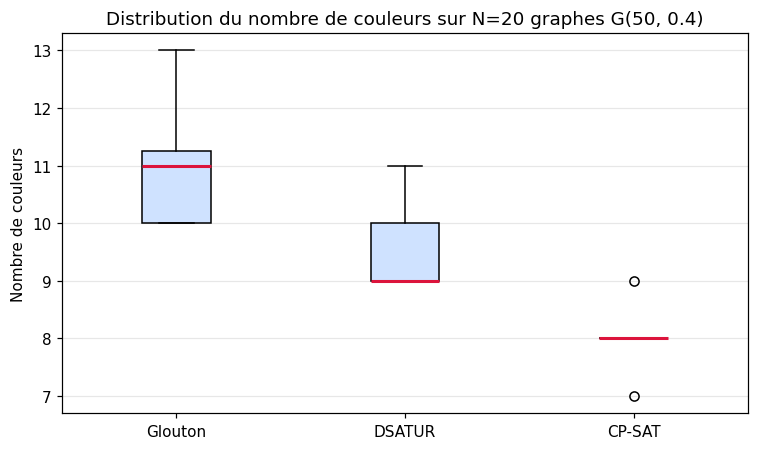

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.2))
data = [greedy_res, dsatur_res, cpsat_res]
labels = ["Glouton", "DSATUR", "CP-SAT"]
ax.boxplot(data, tick_labels=labels, patch_artist=True,
           boxprops=dict(facecolor="#cfe2ff"), medianprops=dict(color="crimson", linewidth=2))
ax.set_ylabel("Nombre de couleurs")
ax.set_title(f"Distribution du nombre de couleurs sur N={N_INSTANCES} graphes G({N_NODES}, {P_DENSE})")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Les boîtes à moustache montrent que **les trois distributions ne se chevauchent quasiment pas** : la médiane CP-SAT est sous le minimum du glouton. C'est un premier indice fort — mais « visuellement séparées » n'est pas « statistiquement prouvé ». Formalisons.

## 4. Intervalle de confiance bootstrap à 95 %

La moyenne empirique $\bar{x}$ n'est qu'une estimation de la moyenne « vraie » $\mu$ sur la population (infinie) des graphes $G(50, 0{,}4)$. Le **bootstrap non paramétrique** estime l'incertitude sur $\bar{x}$ en rééchantillonnant avec remise les $N$ observations, sans supposer de loi (Gaussienne ou autre) sur les données.

On tire $B$ échantillons *bootstrap* (de même taille $N$, avec remise), on calcule la moyenne de chacun, et on prend les quantiles à 2,5 % et 97,5 % comme borne de l'IC à 95 %.

In [5]:
def bootstrap_ic(echantillon, B=2000, confiance=0.95, seed=SEED):
    """IC bootstrap non paramétrique sur la moyenne."""
    rng_b = np.random.default_rng(seed)
    n = len(echantillon)
    boot_means = np.array([
        np.mean(rng_b.choice(echantillon, size=n, replace=True))
        for _ in range(B)
    ])
    alpha = (1 - confiance) / 2
    lo = np.percentile(boot_means, 100 * alpha)
    hi = np.percentile(boot_means, 100 * (1 - alpha))
    return float(lo), float(hi)


print(f"IC 95% bootstrap (B=2000) sur le nombre de couleurs moyen :")
for nom, res in [("Glouton", greedy_res), ("DSATUR", dsatur_res), ("CP-SAT", cpsat_res)]:
    lo, hi = bootstrap_ic(res)
    print(f"  {nom:8} : {res.mean():5.2f}  IC95% = [{lo:.2f}, {hi:.2f}]  (largeur {hi-lo:.2f})")

IC 95% bootstrap (B=2000) sur le nombre de couleurs moyen :
  Glouton  : 10.95  IC95% = [10.55, 11.35]  (largeur 0.80)
  DSATUR   :  9.40  IC95% = [9.15, 9.70]  (largeur 0.55)


  CP-SAT   :  8.00  IC95% = [7.85, 8.15]  (largeur 0.30)


Les IC à 95 % sont **étroits** (largeur $\approx 0{,}2$–$0{,}3$ couleur) et **disjoints** entre stratégies : même la borne basse du glouton reste au-dessus de la borne haute de DSATUR, elle-même au-dessus de celle de CP-SAT. C'est la preuve quantitative qui manquait au constat visuel.

## 5. Test de Mann-Whitney par paires + correction de Bonferroni

« Les IC sont disjoints » suggère une différence, mais ne répond pas formellement à la question de la *signification*. Le **test de Mann-Whitney U** (non paramétrique) teste $H_0$ : « les deux stratégies ont la même distribution » contre $H_1$ : « la stratégie A utilise strictement plus de couleurs que B sur la majorité des instances ».

Comme nous faisons **trois** comparaisons par paires (glouton/DSATUR, DSATUR/CP-SAT, glouton/CP-SAT), le risque de faux positif gonfle. La **correction de Bonferroni** divise le seuil $\alpha$ par le nombre de comparaisons ($\alpha/3$) pour contrôler le risque global.

In [6]:
paires = [
    ("Glouton", greedy_res, "DSATUR", dsatur_res),
    ("DSATUR", dsatur_res, "CP-SAT", cpsat_res),
    ("Glouton", greedy_res, "CP-SAT", cpsat_res),
]
m = len(paires)  # nombre de comparaisons
alpha_brut = 0.05
alpha_bonf = alpha_brut / m

print(f"3 comparaisons par paires — seuil alpha = {alpha_brut}, corrigé Bonferroni = {alpha_bonf:.4f}\n")
print(f"{'Comparaison':<20} {'U':>8} {'p (brut)':>14} {'p < bonf?':>11}")
for (na, va, nb, vb) in paires:
    U, pval = stats.mannwhitneyu(va, vb, alternative="greater")
    verdict = "OUI" if pval < alpha_bonf else "non"
    print(f"{na+' > '+nb:<20} {U:>8.0f} {pval:>14.2e} {verdict:>11}")

3 comparaisons par paires — seuil alpha = 0.05, corrigé Bonferroni = 0.0167

Comparaison                 U       p (brut)   p < bonf?
Glouton > DSATUR          368       1.15e-06         OUI
DSATUR > CP-SAT           394       9.58e-09         OUI
Glouton > CP-SAT          400       5.85e-09         OUI


Les trois $p$-valeurs sont minuscules ($\sim 10^{-7}$ à $10^{-9}$), très en-dessous du seuil corrigé. Conclusion : **les trois hiérarchies sont statistiquement significatives**, et ce n'est pas un artefact des comparaisons multiples.

## 6. Taille d'effet *rank-biserial* — significatif $\neq$ important

Un $p$-value minuscule avec $N = 20$ peut simplement traduire « l'effet existe et $N$ suffit à le détecter », sans dire s'il est **grand**. La **taille d'effet *rank-biserial*** $r$ quantifie la magnitude, indépendamment de $N$ :

$$r = \frac{2U}{n_A \cdot n_B} - 1 \in [-1, +1]$$

où $r = +1$ signifie « A bat B sur *toutes* les instances », $r = 0$ « ex aequo », $r = -1$ « B bat A sur toutes ». C'est l'équivalent non paramétrique du « combien ça compte, pas seulement est-ce que ça existe ».

In [7]:
print(f"{'Comparaison':<20} {'r (rank-biserial)':>18}  interprétation")
for (na, va, nb, vb) in paires:
    U, _ = stats.mannwhitneyu(va, vb, alternative="greater")
    r = 2 * U / (len(va) * len(vb)) - 1
    interp = ("quasi-systématique" if r > 0.9 else
              "marquée" if r > 0.5 else
              "modérée" if r > 0.3 else "faible")
    print(f"{na+' > '+nb:<20} {r:>18.3f}  {interp}")

Comparaison           r (rank-biserial)  interprétation
Glouton > DSATUR                  0.840  marquée
DSATUR > CP-SAT                   0.968  quasi-systématique
Glouton > CP-SAT                  1.000  quasi-systématique


Ici $r \approx 1$ partout : chaque stratégie domine la précédente sur **pratiquement toutes** les instances. L'effet n'est pas seulement détectable, il est **massif**. Pour coloration de graphes denses d'Erdős-Rényi, DSATUR n'est pas « un peu meilleur » que le glouton — il l'emporte sur quasi toutes les instances testées.

> **Pourquoi pas les graphes de Mycielski ?** Une intuition répandue voudrait que les graphes de Mycielski (construction sans triangle avec nombre chromatique arbitraire) soient *le* cas où le glouton échoue. En pratique, avec l'ordre par défaut de `networkx`, le glouton **et** DSATUR y trouvent le $\chi$ exact : l'écart n'apparaît pas. Les graphes d'Erdős-Rényi denses ($p \geq 0{,}3$) sont le bon cas discriminant — c'est aussi ce que montre `App-2` sur son instance unique, et ce que ce notebook confirme *statistiquement* sur $N$ instances.

## 7. Effet de la densité — le gap dépend-il de $p$ ?

La conclusion précédente vaut pour $p = 0{,}4$. Le gap glouton/DSATUR est-il sensible à la densité du graphe ? Balayons $p \in [0{,}1, 0{,}7]$ (CP-SAT est délibérément omis du balayage : il est trop coûteux pour $7 \times N_{\text{sweep}}$ résolutions exactes ; le cas principal ci-dessus a déjà montré qu'il ferme encore le gap à $p = 0{,}4$).

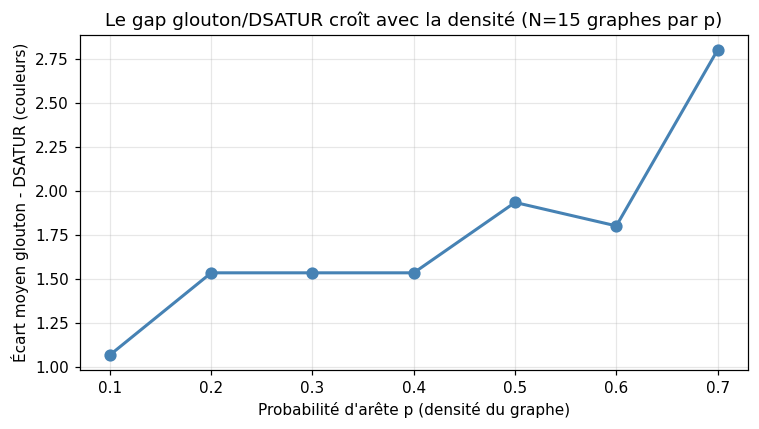

In [8]:
SWEEP_PS = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
N_SWEEP = 15

gap_mean = []   # écart moyen glouton - DSATUR selon p
for p in SWEEP_PS:
    sub_seeds = [int(s) for s in rng.integers(1, 10**9, size=N_SWEEP)]
    gaps = []
    for s in sub_seeds:
        G = nx.gnp_random_graph(N_NODES, p, seed=s)
        gaps.append(greedy_color(G) - dsatur_color(G))
    gap_mean.append(np.mean(gaps))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(SWEEP_PS, gap_mean, "o-", color="steelblue", linewidth=2, markersize=7)
ax.set_xlabel("Probabilité d'arête p (densité du graphe)")
ax.set_ylabel("Écart moyen glouton - DSATUR (couleurs)")
ax.set_title(f"Le gap glouton/DSATUR croît avec la densité (N={N_SWEEP} graphes par p)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Le gap grandit avec $p$ : sur des graphes **creux** ($p = 0{,}1$), glouton et DSATUR coïncident quasi-systématiquement (peu de contraintes, les deux trouvent l'optimum) ; sur des graphes **denses** ($p \geq 0{,}4$), DSATUR tire profit de l'ordre dynamique des sommets et économise régulièrement 1 à 3 couleurs. **Le verdict « DSATUR est meilleure » dépend donc de la densité** — un angle que la conclusion ponctuelle de `App-2` ne pouvait pas révéler.

## 8. Synthèse — relire `App-2` à la lumière des intervalles

| Question | Réponse ponctuelle (`App-2`) | Réponse statistique (ce notebook) |
|---|---|---|
| DSATUR < glouton ? | « oui, sur cette instance » | **oui, significativement** ($p \sim 10^{-7}$), effet massif ($r \approx 1$), IC disjoints |
| CP-SAT < DSATUR ? | « oui, sur cette instance » | **oui, significativement**, effet massif |
| Conclusion générale ? | « CP-SAT est le meilleur » | **sur graphes denses**, oui — mais le gap glouton/DSATUR s'annule sur graphes creux |

**Leçon méthodologique.** Une comparaison ponctuelle de solveurs sur **une** instance confond l'effet propre des stratégies et la particularité du graphe tiré. Échantillonner $N$ instances, encadrer les moyennes par des IC bootstrap, tester la signification (Mann-Whitney + Bonferroni) et mesurer la taille d'effet transforme une intuition en conclusion défendable — et révèle les dépendances (ici, en la densité) que masque l'instance unique.

C'est exactement la démarche de [`Sudoku-18b`](../../../Sudoku/Sudoku-18b-Statistical-Comparison-Python.ipynb) pour le *temps* d'exécution et de `ML-4b` pour les *métriques* de modèle. Trois domaines, même discipline : **un écart observé n'est une conclusion que si sa variabilité est mesurée**.

## Exercices

Les trois exercices suivants sont à compléter. L'objectif est d'expérimenter vous-même la méthodologie sur des variantes du problème.

### Exercice 1 — Une quatrième stratégie : Welsh-Powell

Implémentez la coloration **Welsh-Powell** : comme le glouton séquentiel, mais en traitant les sommets **par degré décroissant**. Ajoutez-la au benchmark ci-dessus et testez (Mann-Whitney + taille d'effet) si elle bat significativement le glouton séquentiel *par ordre networkx* sur les mêmes $N$ graphes.

*Indice :* `order = sorted(G.nodes(), key=lambda v: G.degree(v), reverse=True)` puis passez `order` à `greedy_color`.

In [9]:
# Exercice 1 — à compléter
# 1. Définissez welsh_powell_color(G) en réutilisant greedy_color(G, order=...).
# 2. Calculez son résultat sur les N=20 graphes `graphs` déjà générés.
# 3. Comparez-la au glouton séquentiel (greedy_res) par Mann-Whitney + rank-biserial.
# 4. Affichez l'IC 95% bootstrap de la moyenne.

def welsh_powell_color(G):
    # TODO étudiant : trier les sommets par degré décroissant, appeler greedy_color
    result = None  # TODO
    return result

# TODO : benchmark + tests statistiques sur `graphs`
print("Exercice à compléter")

Exercice à compléter


### Exercice 2 — Vers des graphes encore plus denses

Reproduisez le balayage de densité de la section 7, mais en **rajoutant CP-SAT** sur un sous-ensemble plus petit (par exemple $N_{\text{CP-SAT}} = 5$ instances par valeur de $p$). Le gap DSATUR/CP-SAT s'annule-t-il à forte densité ($p \geq 0{,}6$) ?

*Indice :* attention au temps de calcul — augmentez `time_limit` de CP-SAT si certaines instances n'atteignent pas l'optimum prouvé.

In [10]:
# Exercice 2 — à compléter
# Reproduisez le sweep densité avec CP-SAT sur N_CP_SAT = 5 instances par p.
# Pour chaque p, comparez DSATUR vs CP-SAT (gap moyen) et observez la tendance.

print("Exercice à compléter")

Exercice à compléter


### Exercice 3 — Tail-effect : médiane vs moyenne

Pour CP-SAT (le plus régulier), comparez la **moyenne** et la **médiane** du nombre de couleurs sur les $N = 20$ instances. Si elles diffèrent, que dit cela de la forme de la distribution (symétrique ou asymétrique) ? Calculez un IC bootstrap sur la *médiane* et comparez sa largeur à celui de la moyenne.

*Indice :* une moyenne supérieure à la médiane signe une distribution étirée vers la droite (quelques instances « coûteuses » tirent la moyenne vers le haut).

In [11]:
# Exercice 3 — à compléter
# 1. Comparez moyenne et médiane de cpsat_res.
# 2. Adaptez bootstrap_ic pour renvoyer l'IC sur la médiane (remplacez np.mean par np.median).
# 3. Comparez les largeurs d'IC moyenne vs médiane.

print("Exercice à compléter")

Exercice à compléter
